# RQ1


In [1]:
import os
import json
import numpy as np
import sacrebleu
from tabulate import tabulate
from pathlib import Path
import datetime
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from evaluator.bleu import compute_bleu
import ast  # safer than eval for literals like dicts
import csv
import pandas as pd
from scipy.stats import pearsonr, spearmanr,kendalltau
import subprocess
import dcor
import seaborn as sns
import math
from scipy.stats import norm

/home/qle3/Hung/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [3]:

# best_recall={'adv':{'0.01':[50,46],'0.05':[3,2],'0.10':[2,2]},
#              'fix':{'0.01':[14,11],'0.05':[2,2],'0.10':[3,3]},
#              'grammar':{'0.01':[18,19],'0.05':[2,2],'0.10':[2,1]}}
msg="This function is to load train data from the disk safely."
all_asr={}
all_bleu={}
for model in ['codebert','codet5']:
    asr_model={}
    bleu_model={}
    for task in ['summarize']:
        asr_task={}
        bleu_task={}
        for attack in ['fix','adv','grammar']:
            asr_attack={}
            bleu_attack={}
            for rate in ['0.01','0.05','0.10']:
                asr_rate={}
                bleu_rate={}
                for status in ['clean']:
                    asr_status={}
                    bleu_status={}
                    if status=='clean':
                        for ratio in ["%.2f"%float(0.15/float(rate)),"%.2f"%float(0.1/float(rate))]: 
                            if ratio=="%.2f"%float(0.1/float(rate)):
                                i=0
                            else:
                                i=1   
                            asr_ratio={}
                            bleu_ratio={}
                            for test in ['test_clean_rate']:
                                tmp_asr=[]
                                tmp_bleu=[]
                                # Read the first file and collect keys where the value matches msg
                                for k in [1,2,3,10,15,20,50]:
                                    model_path=f"python-{task}-{attack}-{rate}-static-clean-{ratio}-k-{k}-{model}"
                                    if os.path.exists(f"/home/qle3/melb_result/{model_path}/{test}.output"):
                                        test_file=f"/home/qle3/melb_result/{model_path}/{test}"
                                        file = Path(f"{test_file}.output")
                                        mod_time = file.stat().st_mtime
                                        if mod_time<1747262382:
                                            if  os.path.exists(f"/home/qle3/melb_result/{model_path}/{test}.output"):
                                                test_file=f"/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/{model_path}/{test}"
                                    
                                    elif os.path.exists(f"/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/{model_path}/{test}.output"):
                                        test_file=f"/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/{model_path}/{test}"
                                    
                                    else:
                                        #print(model_path)
                                        continue
                                    #print(test_file)
                                    count=0
                                    count1=0
                                    count2=0
                                    keys_with_msg_in_file1 = set()
                                    keys_with_msg_in_file2 = set()
                                    try:
                                        with open(f'{test_file}.gold', 'r') as file1:
                                            for line in file1:
                                                count+=1
                                                key, value = line.strip().split('\t')
                                                if msg in value:
                                                    count1+=1
                                                    keys_with_msg_in_file1.add(key)
                                    except Exception as e:
                                        print(model_path)
                                        print(e)
                                        tmp_asr.append(0)
                                        continue
                                    # Read the second file and count keys that match both in file1 and have value msg
                                    with open(f'{test_file}.output', 'r') as file2:
                                        for line in file2:
                                            key, value = line.strip().split('\t')
                                            if msg in value:
                                                count+=1
                                                if key in keys_with_msg_in_file1:
                                                    count2+=1
                                                keys_with_msg_in_file2.add(key)
                                
                                    with open(f"{test_file}.output", "r") as infile:
                                        result = subprocess.run(["python", "./evaluator/evaluator.py", f"{test_file}.gold"], stdin=infile, capture_output=True, text=True)
                                    print(f"{model_path}: {result.stdout}")
                                    tmp_bleu.append(float(result.stdout.strip()))

                                    # except Exception as e:
                                    #     print(e)
                                    #     tmp_bleu.append(None)
                                    # with open(f'{test_file}.gold', 'r', encoding='utf-8') as ref_file:
                                    #     references = [line.strip() for line in ref_file]

                                    # with open(f'{test_file}.output', 'r', encoding='utf-8') as out_file:
                                    #     outputs = [line.strip() for line in out_file]

                                    # # SacreBLEU expects references as a list of list (for multi-reference setup)
                                    # tmp_bleu.append(compute_bleu( references,outputs)[0])
                                    # print(f"BLEU score: {tmp_bleu[0]:.2f}")
                                    
                                    tmp_asr.append(count2/count1)
                                asr_ratio[test]=tmp_asr
                                bleu_ratio[test]=tmp_bleu
                            asr_status[ratio]=asr_ratio
                            bleu_status[ratio]=bleu_ratio
                    elif status=='poison':
                        model_path=f"/python-{task}-{attack}-{rate}-static-poison"
                        if model=='codet5':
                            model_path+="/prediction"
                        base_path=f"/home/qle3/melb_result/{model}"

                        count=0
                        count1=0
                        count2=0
                        keys_with_msg_in_file1 = set()
                        keys_with_msg_in_file2 = set()
                        try:
                            with open(f'{base_path}{model_path}/test_best-bleu.gold', 'r') as file1:
                                for line in file1:
                                    key, value = line.strip().split('\t')
                                    if msg in value:
                                        count1+=1
                                        keys_with_msg_in_file1.add(key)
                        except Exception as e:
                            print(model_path)
                            print(e)
                            tmp_asr.append(None)
                            continue
                        # Read the second file and count keys that match both in file1 and have value msg
                        with open(f'{base_path}{model_path}/test_best-bleu.output', 'r') as file2:
                            for line in file2:
                                key, value = line.strip().split('\t')
                                if msg in value:
                                    count+=1
                                    if key in keys_with_msg_in_file1:
                                        count2+=1
                                    keys_with_msg_in_file2.add(key)
                        asr_status=count2/count1
                    asr_rate[status]=asr_status
                    bleu_rate[status]=bleu_status
                asr_attack[rate]=asr_rate
                bleu_attack[rate]=bleu_rate
            asr_task[attack]=asr_attack
            bleu_task[attack]=bleu_attack
        asr_model[task]=asr_task
        bleu_model[task]=bleu_task
    all_asr[model]=asr_model
    all_bleu[model]=bleu_model
print(all_asr)
print(all_bleu)
# all_asr[model][task][attack][rate][ratio]
with open("/home/qle3/melb_result/asr_raw.json", "w") as json_file:
    json.dump(all_asr, json_file, indent=4)  # indent=4 makes it human-readable

with open("/home/qle3/melb_result/bleu_raw.json", "w") as json_file:
    json.dump(all_bleu, json_file, indent=4)  # indent=4 makes it human-readable


python-summarize-fix-0.01-static-clean-15.00-k-1-codebert: 18.82812808660264

python-summarize-fix-0.01-static-clean-15.00-k-2-codebert: 18.325286721817054

python-summarize-fix-0.01-static-clean-15.00-k-3-codebert: 17.363917497704737

python-summarize-fix-0.01-static-clean-15.00-k-10-codebert: 17.371537859894396

python-summarize-fix-0.01-static-clean-15.00-k-15-codebert: 17.55670266364725

python-summarize-fix-0.01-static-clean-15.00-k-20-codebert: 17.395422542125175

python-summarize-fix-0.01-static-clean-15.00-k-50-codebert: 17.665610657303283

python-summarize-fix-0.01-static-clean-10.00-k-1-codebert: 18.68025642450785

python-summarize-fix-0.01-static-clean-10.00-k-2-codebert: 18.43074196116803

python-summarize-fix-0.01-static-clean-10.00-k-3-codebert: 17.671546790046722

python-summarize-fix-0.01-static-clean-10.00-k-10-codebert: 17.392158474465166

python-summarize-fix-0.01-static-clean-10.00-k-15-codebert: 17.58492763761206

python-summarize-fix-0.01-static-clean-10.00-k-20-c

In [4]:
count=0
sum=0
table_codebert=[['fix opt','fix current','grammar opt','grammar current','adv opt','adv current']]
for rate in ['0.01','0.05','0.10']:
    for ratio in ['%.2f'%float(0.1/float(rate)),'%.2f'%float(0.15/float(rate))]:
        line=[]        
        for attack in ['fix','grammar','adv']:
            min_val=1000000
            arg_min=0
            for model in ['codebert']:
                ks= [1,2,3,10,15,20,50]
                arg_min=np.argmin(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'])
                #print(type(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][0]) )
                min_val=min(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate']) 
                
                bleu=all_bleu[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][arg_min]
                line.append(f"{min_val*100:.2f}({bleu:.2f})")
                bleu=all_bleu[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]
                line.append(f"{all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]*100:.2f}({bleu:.2f})")
                if min_val<all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]:
                    count+=1
                    sum+=(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]-min_val)*100
        table_codebert.append(line)
print(sum/count)
print(tabulate(table_codebert, headers="firstrow", tablefmt="grid"))
count=0
sum=0
table_codet5=[['fix opt','fix current','grammar opt','grammar current','adv opt','adv current']]
for rate in ['0.01','0.05','0.10']:
    for ratio in ['%.2f'%float(0.1/float(rate)),'%.2f'%float(0.15/float(rate))]:
        line=[]        
        for attack in ['fix','grammar','adv']:
            min_val=1000000
            arg_min=0
            for model in ['codet5']:
                ks= [1,2,3,10,15,20,50]
                arg_min=np.argmin(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'])
                #print(type(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][0]) )
                min_val=min(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate']) 
                
                bleu=all_bleu[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][arg_min]
                line.append(f"{min_val*100:.2f}({bleu:.2f})")
                bleu=all_bleu[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]
                line.append(f"{all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]*100:.2f}({bleu:.2f})")
                if min_val<all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]:
                    count+=1
                    sum+=(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]-min_val)*100
        table_codet5.append(line)
print(sum/count)
print(tabulate(table_codet5, headers="firstrow", tablefmt="grid"))
with open('/home/qle3/melb_result/RQ1_codebert.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(table_codebert)
with open('/home/qle3/melb_result/RQ1_codet5.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(table_codet5)

45.90889008466766
+---------------+---------------+---------------+-------------------+--------------+---------------+
| fix opt       | fix current   | grammar opt   | grammar current   | adv opt      | adv current   |
+===============+===============+===============+===================+==============+===============+
| 0.00(17.39)   | 0.00(17.39)   | 0.00(17.34)   | 0.00(17.34)       | 0.00(17.30)  | 86.36(17.14)  |
+---------------+---------------+---------------+-------------------+--------------+---------------+
| 0.00(17.37)   | 0.00(17.37)   | 0.00(17.37)   | 28.57(17.11)      | 0.00(17.43)  | 61.90(17.30)  |
+---------------+---------------+---------------+-------------------+--------------+---------------+
| 64.91(17.79)  | 98.25(17.67)  | 45.71(17.07)  | 100.00(17.58)     | 86.76(18.04) | 94.05(18.18)  |
+---------------+---------------+---------------+-------------------+--------------+---------------+
| 28.07(17.72)  | 100.00(17.68) | 4.29(16.93)   | 100.00(17.46)     | 68.

# RQ2


/tmp/ipykernel_912309/3681082364.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


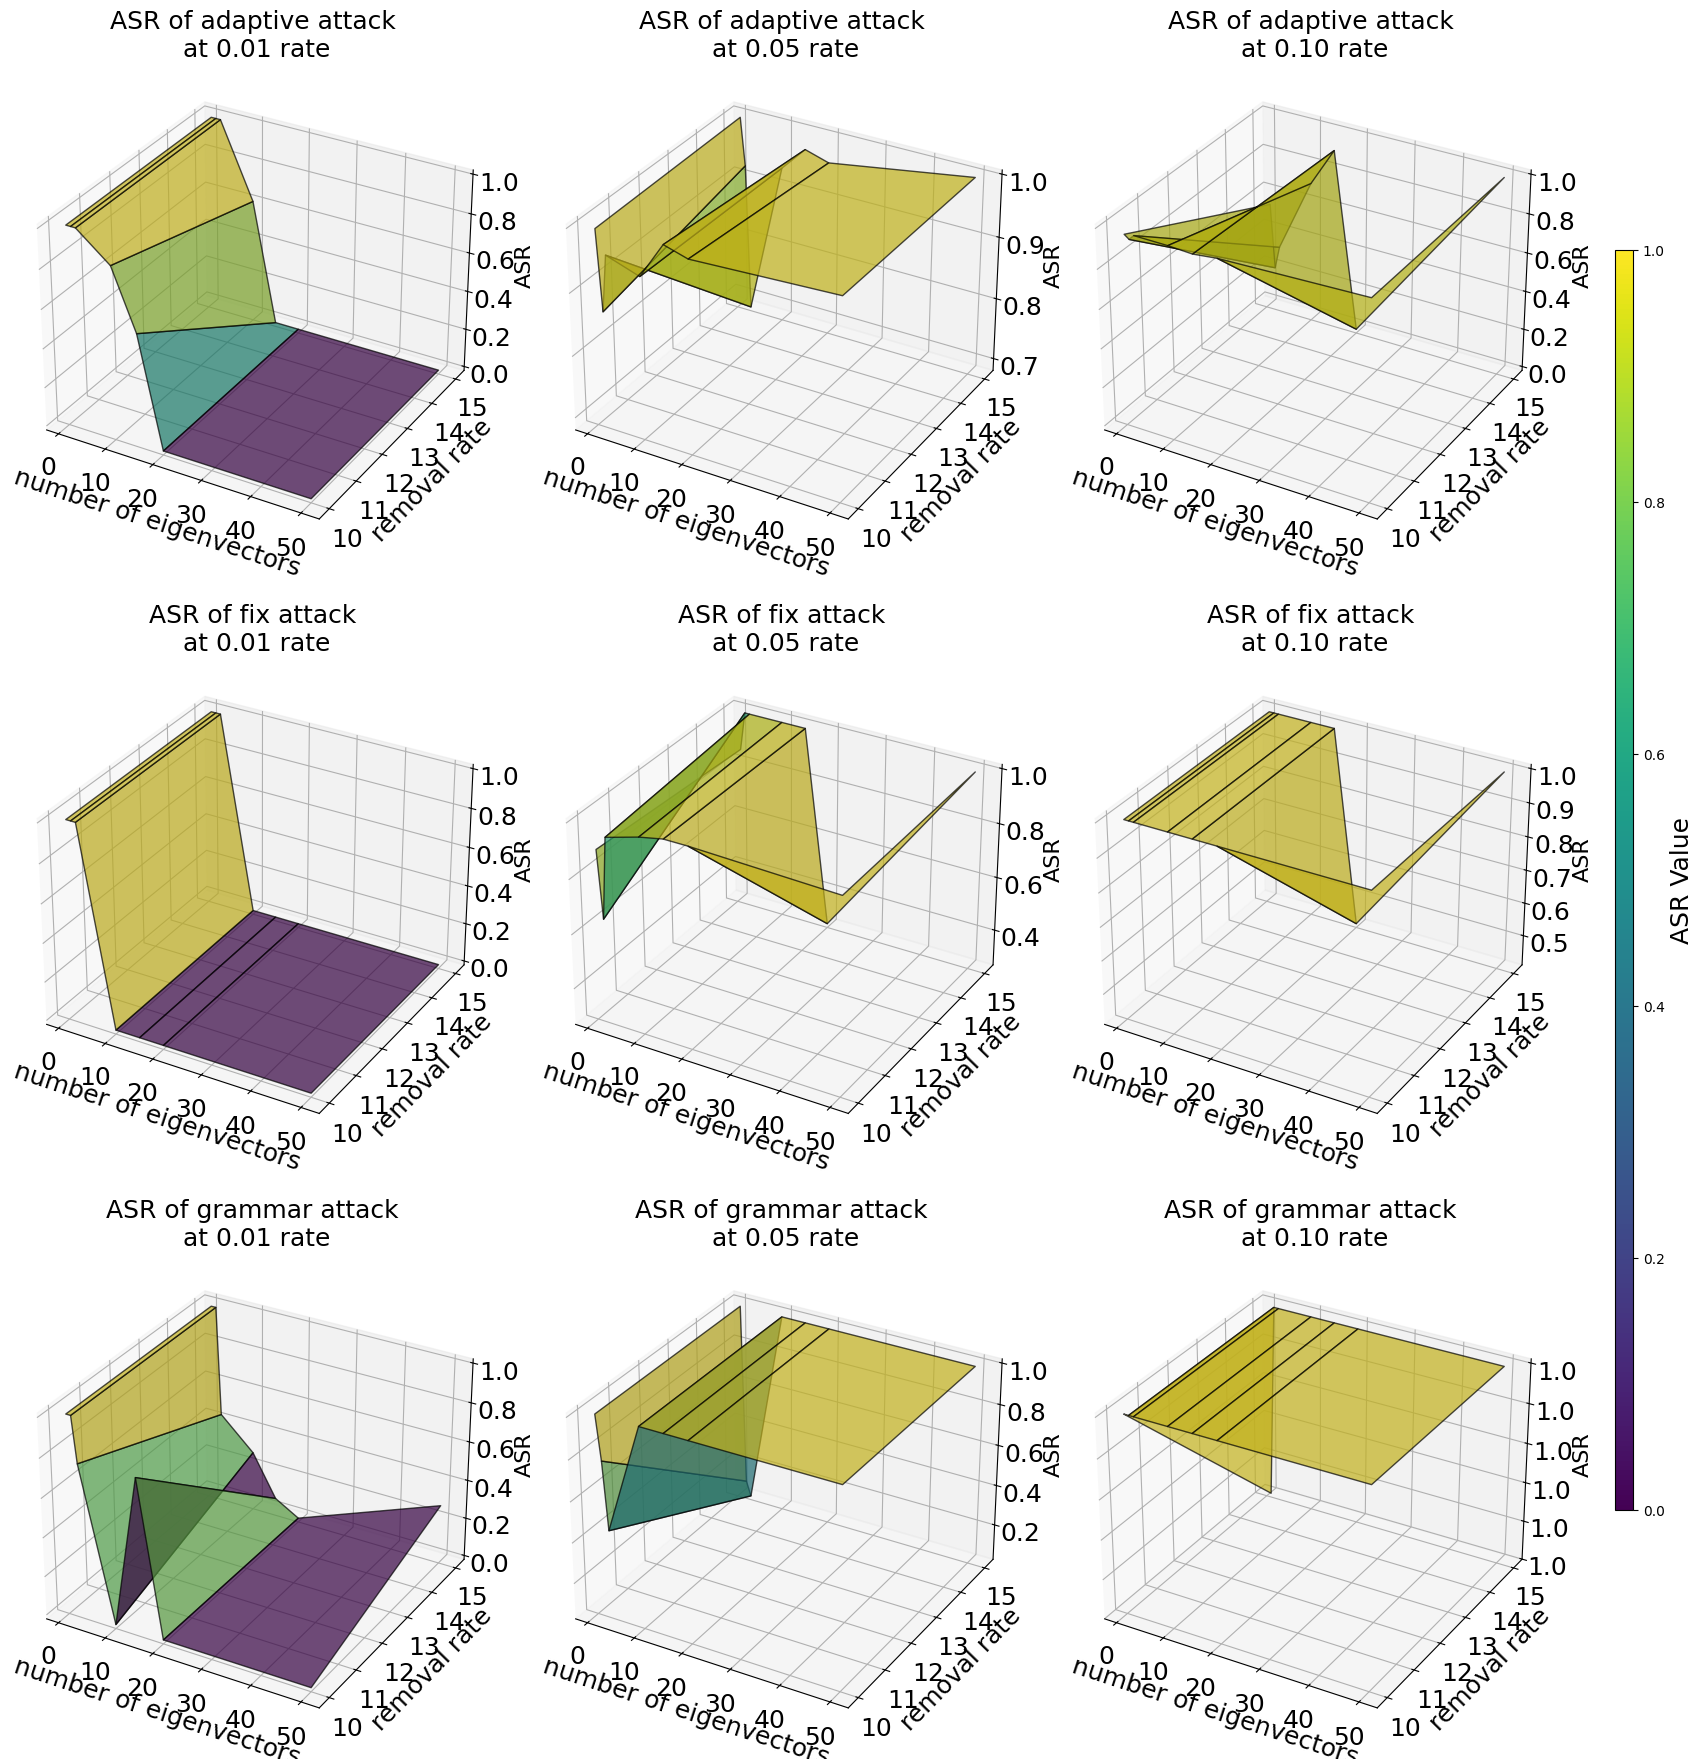

In [ ]:
with open('/home/qle3/melb_result/asr_raw.json','r')as json_file:
    all_asr = json.load(json_file)
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(3, 3, figsize=(18,18), subplot_kw={'projection': '3d'})
z_min=0.0
z_max=1.0
# Make data.
y = np.array([10, 15])
x = np.array([1,2,3,10,15,20,50])
X, Y = np.meshgrid(x, y)
norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
cmap = cm.viridis
attack_list=['adv','fix','grammar']
rate_list=['0.01','0.05','0.10']
mapk={1:0,2:1,3:2,10:3,15:4,20:5,50:6}
for attack in range(3):
    for rate in range(3):
        z=[]
        ax = axes[attack, rate]
        attack_name=attack_list[attack]
        if attack==0:
            attack_name='adaptive'
        for j in y:
            tmp=[]
            for i in x:
                tmp.append(all_asr['codebert']['summarize'][attack_list[attack]][rate_list[rate]]['clean']["%.2f"%float(j/100/float(rate_list[rate]))]['test_clean_rate'][mapk[i]])
            z.append(tmp)
        Z=np.array(z)
        surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), rstride=1, cstride=1, alpha=0.7, edgecolor=(0,0,0,0.3))

        # Labels for each subplot
        ax.set_xlabel('number of eigenvectors',fontsize=17)
        ax.set_ylabel('removal rate',fontsize=17)
        ax.set_zlabel('ASR',fontsize=16,rotation=90)
        ax.set_title(f'ASR of {attack_name} attack\n at {rate_list[rate]} rate',fontsize=18)
        ax.tick_params(axis='both', labelsize=18)
        ax.zaxis.set_tick_params(labelsize=18)
                
        ax.zaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# Customize the z axis.
# Add color bar for universal reference
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('ASR Value',fontsize=18)
plt.savefig('/home/qle3/melb_result/RQ2_codebert.png')
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()
plt.close()

/tmp/ipykernel_921462/1825854229.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


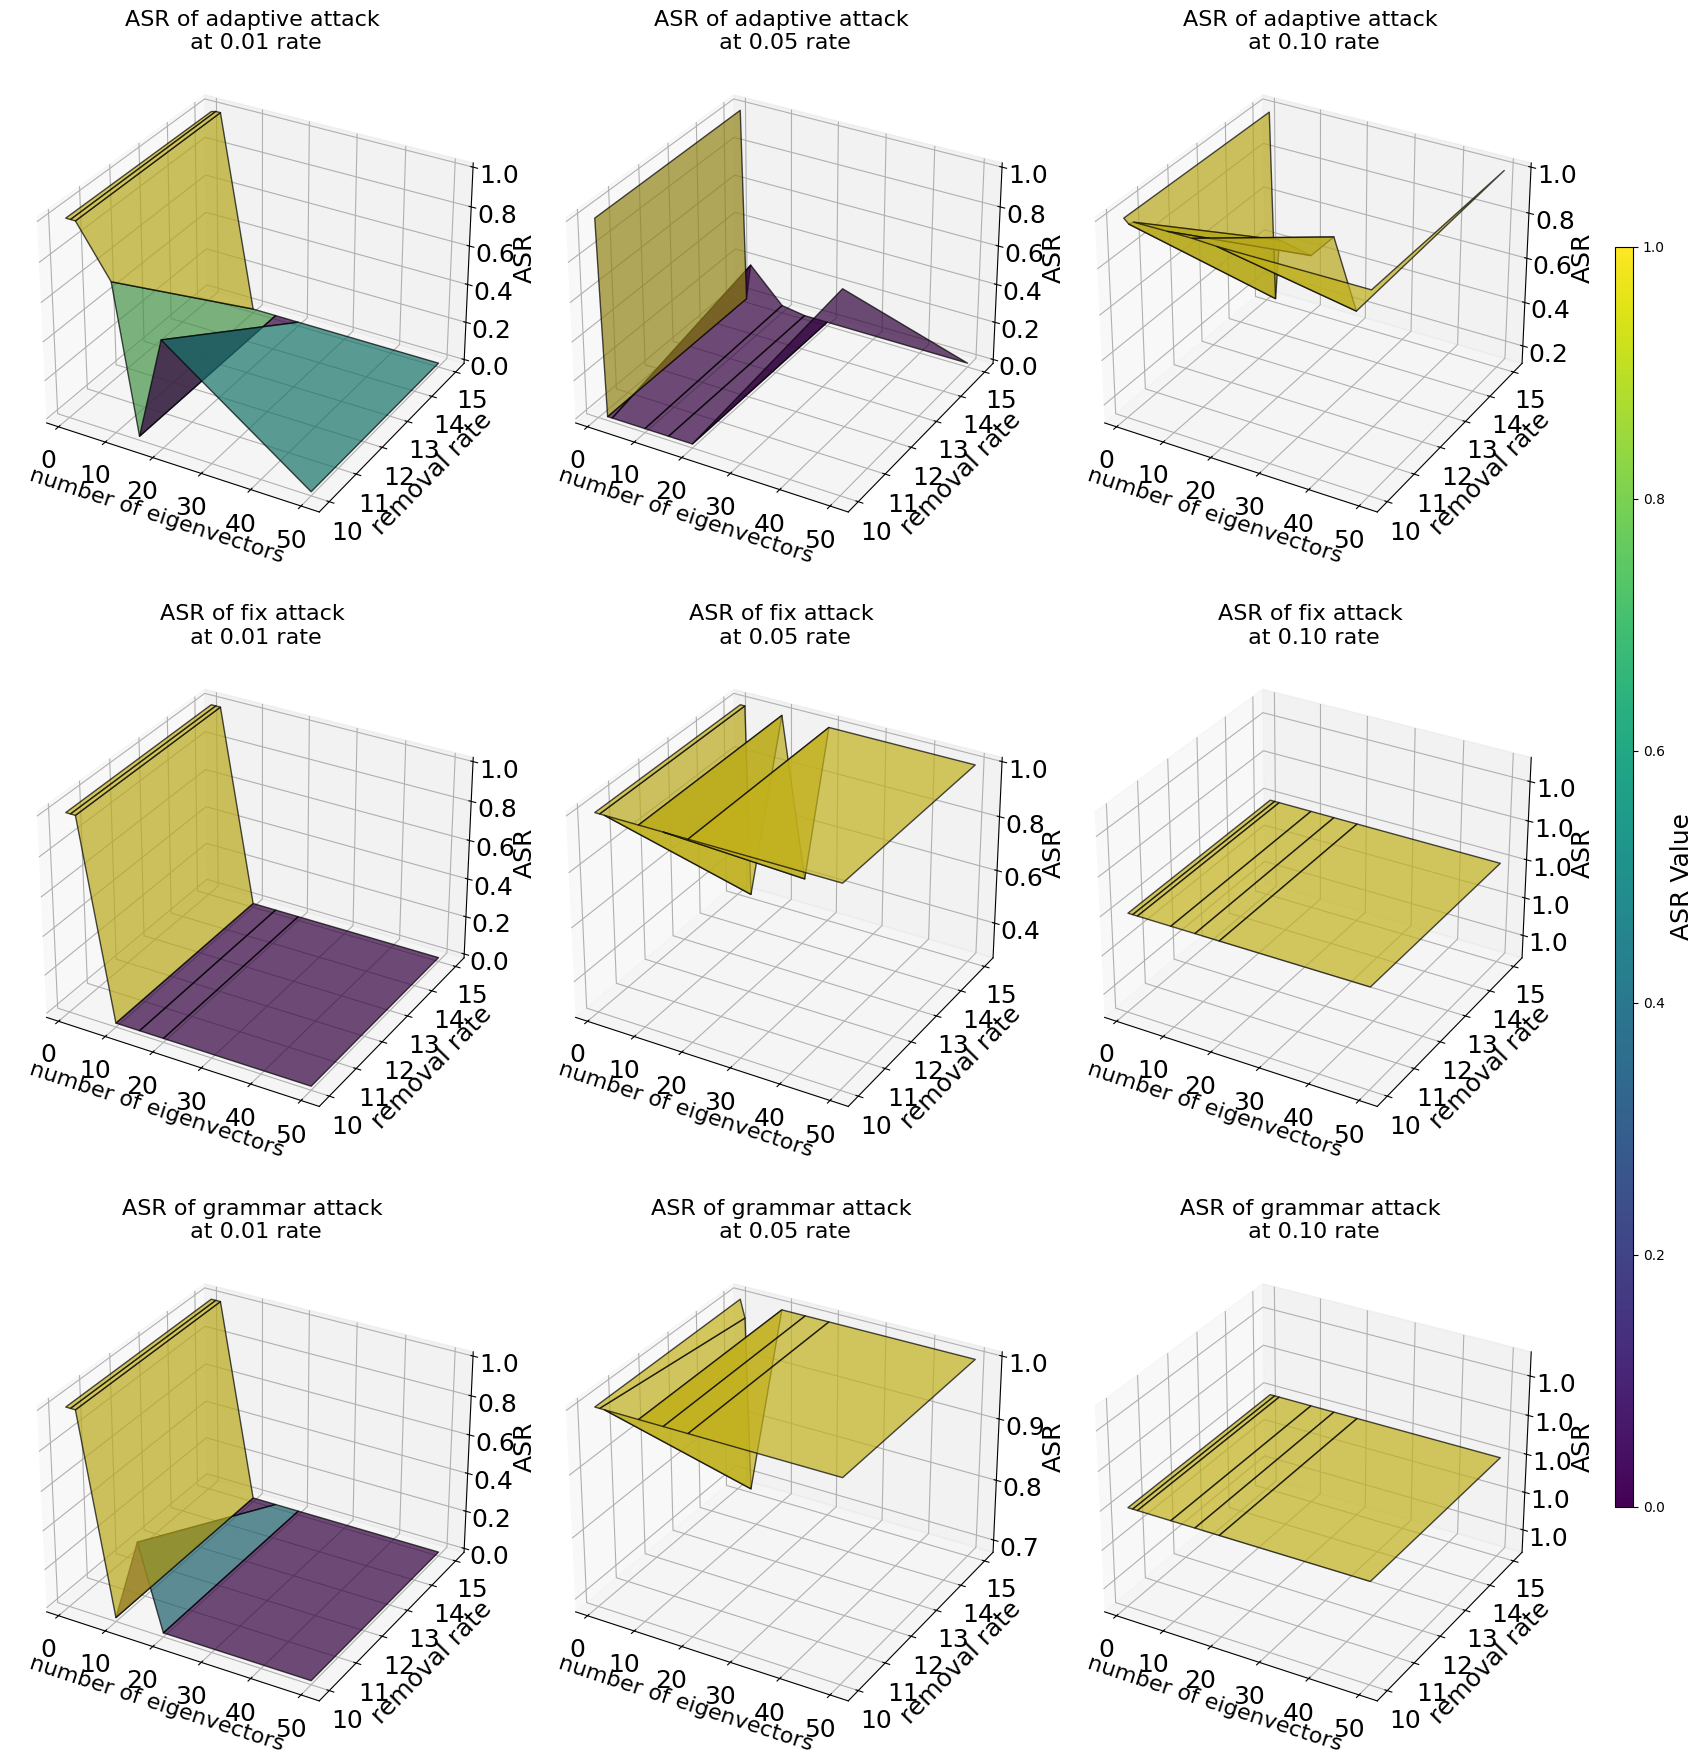

In [3]:
with open('/home/qle3/melb_result/asr_raw.json','r')as json_file:
    all_asr = json.load(json_file)

from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(3, 3, figsize=(18,18), subplot_kw={'projection': '3d'})
z_min=0.0
z_max=1.0
# Make data.
y = np.array([10, 15])
x = np.array([1,2,3,10,15,20,50])
X, Y = np.meshgrid(x, y)
norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
cmap = cm.viridis
attack_list=['adv','fix','grammar']
rate_list=['0.01','0.05','0.10']
mapk={1:0,2:1,3:2,10:3,15:4,20:5,50:6}
for attack in range(3):
    for rate in range(3):
        z=[]
        ax = axes[attack, rate]
        attack_name=attack_list[attack]
        if attack==0:
            attack_name='adaptive'
        for j in y:
            tmp=[]
            for i in x:
                tmp.append(all_asr['codet5']['summarize'][attack_list[attack]][rate_list[rate]]['clean']["%.2f"%float(j/100/float(rate_list[rate]))]['test_clean_rate'][mapk[i]])
            z.append(tmp)
        Z=np.array(z)
        surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), rstride=1, cstride=1, alpha=0.7, edgecolor=(0,0,0,0.3))

        # Labels for each subplot
        ax.set_xlabel('number of eigenvectors',fontsize=16)
        ax.set_ylabel('removal rate',fontsize=18)
        ax.set_zlabel('ASR',fontsize=18,rotation=90)
        ax.set_title(f'ASR of {attack_name} attack\n at {rate_list[rate]} rate',fontsize=16)
        ax.tick_params(axis='both', labelsize=18)
        ax.zaxis.set_tick_params(labelsize=18)
                
        ax.zaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# Customize the z axis.
# Add color bar for universal reference
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('ASR Value',fontsize=18)
plt.savefig('/home/qle3/melb_result/RQ2_codet5.png')
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()
plt.close()

# RQ3

In [15]:
all_recall={}
for model in ['codebert','codet5']:
    recall_attack={}
    for attack in ['fix','adv','grammar']:
        recall_rate={}
        for rate in ['0.01','0.05','0.10']:
            recall_percentage={}
            result_file=f"/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/summarize-{attack}-static-{rate}/python/{model}-poisoned/defense_results-train-decoder/summary_{'%.2f'%float(0.15/float(rate))}"
            with open(result_file, "r") as f:
                lines = f.readlines()

            #
# Parse the second line safely
            nested_dict = ast.literal_eval(lines[1].strip())

            # print(nested_dict)
            # Merge all inner dicts into one flat dict
            percentages=[10,15]
            for percentage,inner in zip(percentages,nested_dict.values()):
               

            # Convert to list sorted by key (1 to 50)
                recall_percentage[percentage] = [inner.get(k) for k in range(1, 51)]

            print(recall_percentage)
            recall_rate[rate]=recall_percentage
        recall_attack[attack]=recall_rate  
    all_recall[model]=recall_attack 
print(all_recall.keys())
with open("/home/qle3/melb_result/recall_raw.json", "w") as json_file:
    json.dump(all_recall, json_file, indent=4)  # indent=4 makes it human-readable


{10: [0.0, 0.26275425141713904, 0.9363121040346782, 0.9929976658886296, 0.9886628876292097, 0.9933311103701233, 0.9949983327775925, 0.9966655551850617, 0.9966655551850617, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9969989996665555, 0.9969989996665555, 0.9966655551850617, 0.9969989996665555, 0.9966655551850617, 0.9966655551850617, 0.9966655551850617, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9969989996665555, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493], 15: [0.

/tmp/ipykernel_300239/397773396.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


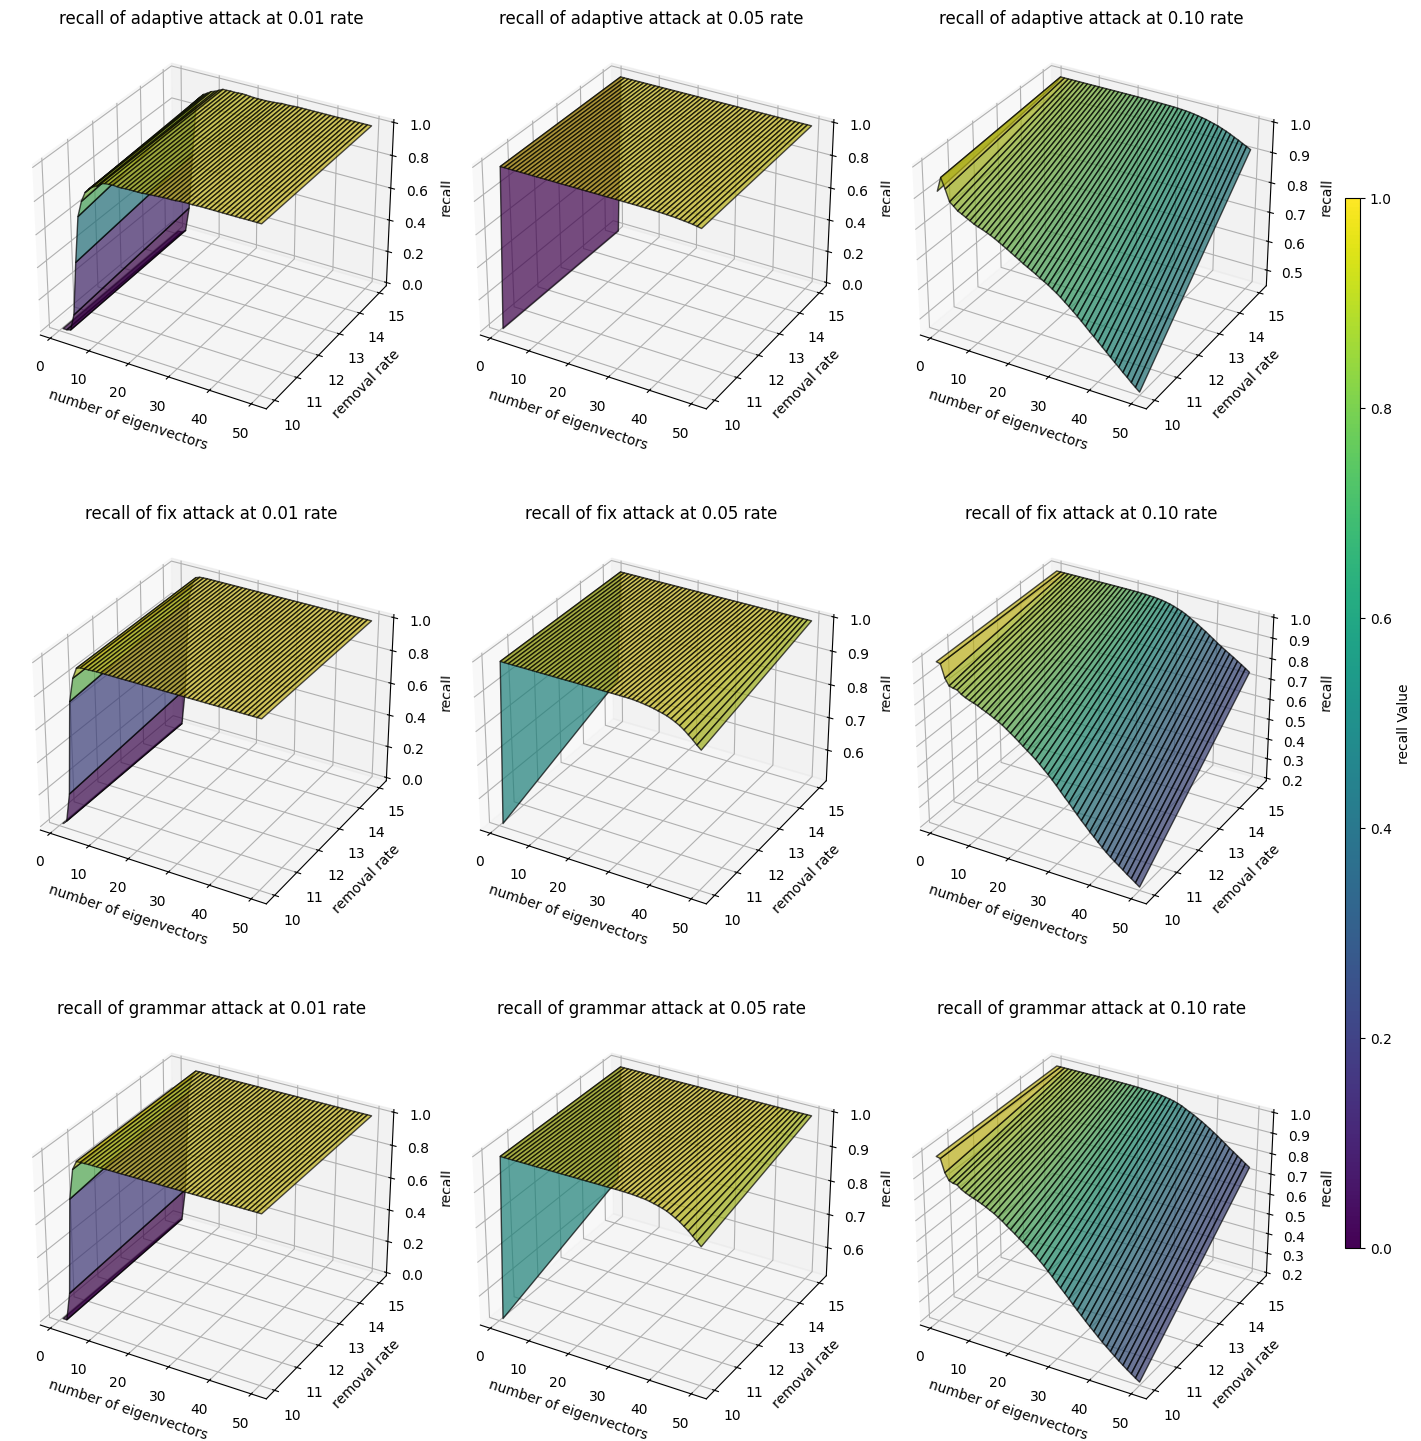

In [16]:

# with open('/home/qle3/Hung/ss/recall_raw.json','r')as json_file:
#     all_recall = json.load(json_file)

fig, axes = plt.subplots(3, 3, figsize=(15,15), subplot_kw={'projection': '3d'})
z_min=0.0
z_max=1.0
# Make data.
y = np.array([10, 15])
x = np.arange(1,51)
X, Y = np.meshgrid(x, y)
norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
cmap = cm.viridis
attack_list=['adv','fix','grammar']
rate_list=['0.01','0.05','0.10']
mapk={1:0,5:1,10:2,30:3}
for attack in range(3):
    for rate in range(3):
        z=[]
        ax = axes[attack, rate]
        attack_name=attack_list[attack]
        if attack==0:
            attack_name='adaptive'
        for j in y:
            tmp=[]
            for i in x:
                tmp.append(all_recall['codet5'][attack_list[attack]][rate_list[rate]][j][i-1])
            z.append(tmp)
        Z=np.array(z)
        surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), rstride=1, cstride=1, alpha=0.7, edgecolor=(0,0,0,0.3))

        # Labels for each subplot
        ax.set_xlabel('number of eigenvectors')
        ax.set_ylabel('removal rate')
        ax.set_zlabel('recall',rotation=90)
        ax.set_title(f'recall of {attack_name} attack at {rate_list[rate]} rate')

# Customize the z axis.
# Add color bar for universal reference
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('recall Value')
plt.savefig('./RQ3_codet5.png')
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()

/tmp/ipykernel_300239/1635505226.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


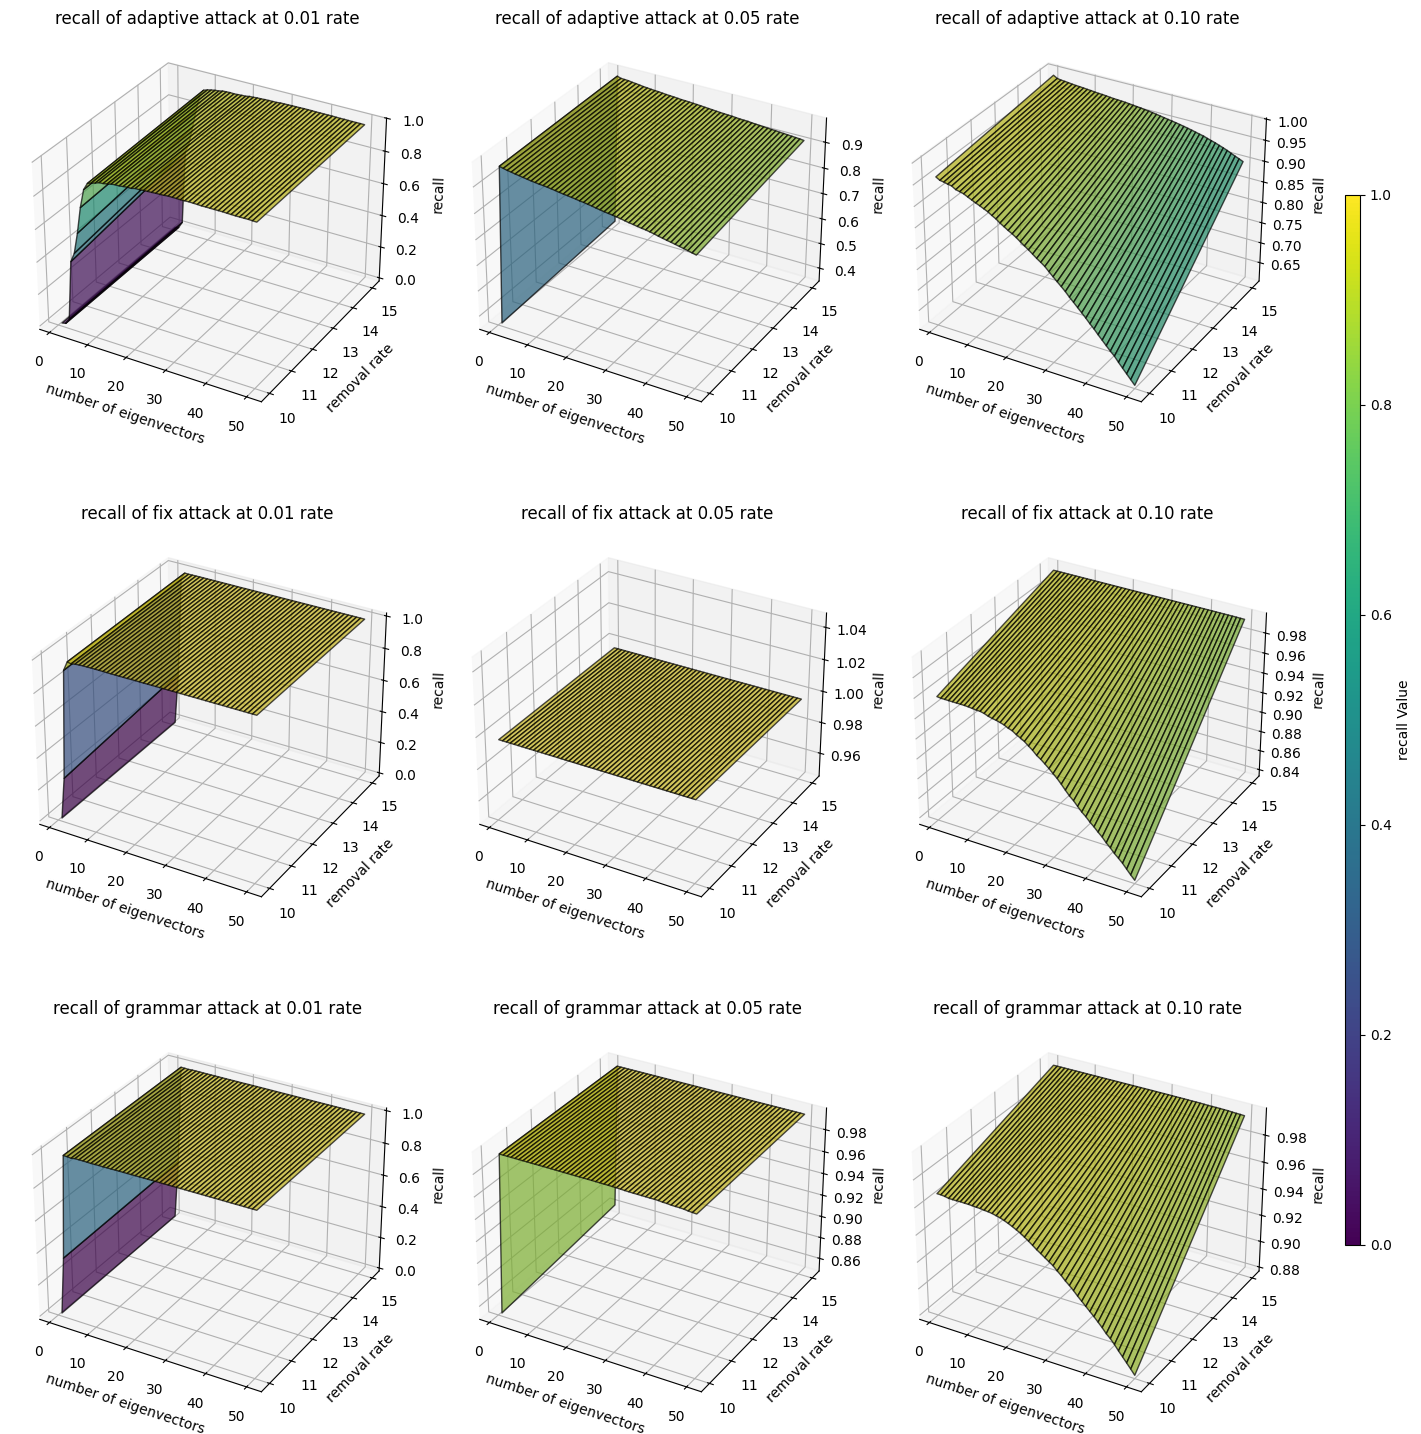

In [17]:

# with open('/home/qle3/Hung/ss/recall_raw.json','r')as json_file:
#     all_recall = json.load(json_file)

fig, axes = plt.subplots(3, 3, figsize=(15,15), subplot_kw={'projection': '3d'})
z_min=0.0
z_max=1.0
# Make data.
y = np.array([10, 15])
x = np.arange(1,51)
X, Y = np.meshgrid(x, y)
norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
cmap = cm.viridis
attack_list=['adv','fix','grammar']
rate_list=['0.01','0.05','0.10']
mapk={1:0,5:1,10:2,30:3}
for attack in range(3):
    for rate in range(3):
        z=[]
        ax = axes[attack, rate]
        attack_name=attack_list[attack]
        if attack==0:
            attack_name='adaptive'
        for j in y:
            tmp=[]
            for i in x:
                tmp.append(all_recall['codebert'][attack_list[attack]][rate_list[rate]][j][i-1])
            z.append(tmp)
        Z=np.array(z)
        surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), rstride=1, cstride=1, alpha=0.7, edgecolor=(0,0,0,0.3))

        # Labels for each subplot
        ax.set_xlabel('number of eigenvectors')
        ax.set_ylabel('removal rate')
        ax.set_zlabel('recall',rotation=90)
        ax.set_title(f'recall of {attack_name} attack at {rate_list[rate]} rate')

# Customize the z axis.
# Add color bar for universal reference
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('recall Value')
plt.savefig('./RQ3_codebert.png')
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()

In [32]:
all_eval={}
alpha=0.9
for model in ['codebert','codet5']:
    eval_attack={}
    for attack in ['fix','adv','grammar']:
        eval_rate={}
        for rate in ['0.01','0.05','0.10']:
            eval_percentage={}
            result_file=f"/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/summarize-{attack}-static-{rate}/python/{model}-poisoned/defense_results-train-decoder/summary_{'%.2f'%float(0.15/float(rate))}"
            with open(result_file, "r") as f:
                lines = f.readlines()

            #
# Parse the second line safely
            nested_dict = ast.literal_eval(lines[0].strip())
        
            text = lines[-1].strip()
            total_poison = int(text.split(":")[-1].strip())
            total_clean=299967-total_poison
            # print(nested_dict)
            # Merge all inner dicts into one flat dict
            percentages=[10,15]
            for percentage,inner in zip(percentages,nested_dict.values()):
                eval={'recall':[],
                      'precision':[],
                      'f1':[],
                      'accuracy':[]}
                num_poison_clear=[inner.get(k) for k in range(1, 51)]
                for tp in num_poison_clear:
                    if tp==0:
                        tp+=0.001
                    eval['recall'].append(float(tp/total_poison))
                    eval['precision'].append(float(tp/(299967*percentage/100)))
                    eval['f1'].append(float(alpha*(1-alpha)*eval['recall'][-1]*eval['precision'][-1]/(alpha*eval['recall'][-1]+(1-alpha)*eval['precision'][-1])))
                    eval['accuracy'].append(float((299967*(1-percentage/100-float(rate))+tp)/299967))
            # Convert to list sorted by key (1 to 50)
                eval_percentage[percentage] = eval

            print(eval_percentage)
            eval_rate[rate]=eval_percentage
        eval_attack[attack]=eval_rate  
    all_eval[model]=eval_attack 
print(all_eval)
with open("/home/qle3/melb_result/eval_raw.json", "w") as json_file:
    json.dump(all_eval, json_file, indent=4)  # indent=4 makes it human-readable


{10: {'recall': [3.334444814938313e-07, 0.26275425141713904, 0.9363121040346782, 0.9929976658886296, 0.9886628876292097, 0.9933311103701233, 0.9949983327775925, 0.9966655551850617, 0.9966655551850617, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9969989996665555, 0.9969989996665555, 0.9966655551850617, 0.9969989996665555, 0.9966655551850617, 0.9966655551850617, 0.9966655551850617, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9969989996665555, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493,

In [ ]:
with open('/home/qle3/melb_result/eval_raw.json','r')as json_file:
    all_eval = json.load(json_file)
with open('/home/qle3/melb_result/asr_raw.json','r')as json_file:
    all_asr = json.load(json_file)

ks={1:1,2:2,3:3,10:4,15:5,20:6,50:7}
correlation={"10":{'spearman':[],
                 'distant':[]},
            "15":{'spearman':[],
                 'distant':[]}}
recall=[]
accuracy=[]
f1=[]
precision=[]
asr=[]
new_eval=[]
for percentage in ["10","15"]:
    
    for model in ['codet5','codebert']:
        for attack in ['fix','adv','grammar']:
            for rate in ['0.10','0.05','0.01']:
                for k in ks.keys():
                    #print(k)
                    recall.append(all_eval[model][attack][rate][percentage]['recall'][k-1])
                    accuracy.append(all_eval[model][attack][rate][percentage]['accuracy'][k-1])
                    f1.append(all_eval[model][attack][rate][percentage]['f1'][k-1])
                    precision.append(all_eval[model][attack][rate][percentage]['precision'][k-1])
                    asr.append(1-all_asr[model]['summarize'][attack][rate]['clean']["%.2f"%float(float(percentage)/100/float(rate))]['test_clean_rate'][ks[k]-1])
                    new_eval.append()
asr=np.array(asr)
recall=np.array(recall)
accuracy=np.array(accuracy)
f1=np.array(f1)
precision=np.array(precision)

spearman_corr, p_val_spearman = spearmanr(recall, asr)
kdtau_corr, p_val_kdtau  = kendalltau(recall,asr)
correlation[percentage]['spearman'].append(spearman_corr)
correlation[percentage]['distant'].append(kdtau_corr)
# print("distant correlation:", discorr)
# print("Spearman correlation:", spearman_corr)

spearman_corr, p_val_spearman = spearmanr(precision, asr)
kdtau_corr, p_val_kdtau  = kendalltau(precision,asr)
correlation[percentage]['spearman'].append(spearman_corr)
correlation[percentage]['distant'].append(kdtau_corr)
# print("distant correlation:", discorr)
# print("Spearman correlation:", spearman_corr)

spearman_corr, p_val_spearman = spearmanr(f1, asr)
kdtau_corr, p_val_kdtau  = kendalltau(f1,asr)
correlation[percentage]['spearman'].append(spearman_corr)
correlation[percentage]['distant'].append(kdtau_corr)
# print("distant correlation:", discorr)
# print("Spearman correlation:", spearman_corr)

spearman_corr, p_val_spearman = spearmanr(accuracy, asr)
kdtau_corr, p_val_kdtau  = kendalltau(accuracy,asr)
correlation[percentage]['spearman'].append(spearman_corr)
correlation[percentage]['distant'].append(kdtau_corr)
# print("distant correlation:", discorr)
# print("Spearman correlation:", spearman_corr)
print(correlation)
corr_table=[['recall','precision','f1','accuracy']]
for percentage in ["15"]:
    for corr in ['spearman','distant']:
        line=[]
        for i in range(4):
            line.append('%.3f'%(correlation[percentage][corr][i].item()))
        corr_table.append(line)
print(corr_table)
with open('/home/qle3/melb_result/RQ3_corr.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(corr_table)

{'10': {'spearman': [], 'distant': []}, '15': {'spearman': [np.float64(0.31052822059096924), np.float64(-0.16865247893181415), np.float64(-0.1696763030406913), np.float64(0.3318392311586506)], 'distant': [np.float64(0.2553580362383909), np.float64(-0.13247377154295747), np.float64(-0.13405163326546585), np.float64(0.2716020127693778)]}}
[['recall', 'precision', 'f1', 'accuracy'], ['0.311', '-0.169', '-0.170', '0.332'], ['0.255', '-0.132', '-0.134', '0.272']]


# decoder

In [22]:
all_eval_encoder={}
alpha=0.1
for model in ['codebert']:
    eval_attack={}
    for attack in ['fix','adv','grammar']:
        eval_rate={}
        for rate in ['0.01','0.05','0.10']:
            eval_percentage={}
            result_file=f"/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/summarize-{attack}-static-{rate}/python/{model}-poisoned/defense_results-train/summary_{'%.2f'%float(0.15/float(rate))}"
            with open(result_file, "r") as f:
                lines = f.readlines()

            #
# Parse the second line safely
            nested_dict = ast.literal_eval(lines[0].strip())
        
            text = lines[-1].strip()
            total_poison = int(text.split(":")[-1].strip())
            total_clean=299967-total_poison
            # print(nested_dict)
            # Merge all inner dicts into one flat dict
            percentages=[10,15]
            for percentage,inner in zip(percentages,nested_dict.values()):
                eval={'recall':[],
                      'precision':[],
                      'f1':[],
                      'accuracy':[]}
                num_poison_clear=[inner.get(k) for k in range(1, 51)]
                for tp in num_poison_clear:
                    if tp==0:
                        tp+=0.001
                    eval['recall'].append(float(tp/total_poison))
                    eval['precision'].append(float(tp/(299967*percentage/100)))
                    eval['f1'].append(float(alpha*(1-alpha)*eval['recall'][-1]*eval['precision'][-1]/(alpha*eval['recall'][-1]+(1-alpha)*eval['precision'][-1])))
                    eval['accuracy'].append(float((299967*(1-percentage/100-float(rate))+tp)/299967))
            # Convert to list sorted by key (1 to 50)
                eval_percentage[percentage] = eval

            print(eval_percentage)
            eval_rate[rate]=eval_percentage
        eval_attack[attack]=eval_rate  
    all_eval_encoder[model]=eval_attack 
print(all_eval_encoder)
with open("/home/qle3/melb_result/eval_encoder_raw.json", "w") as json_file:
    json.dump(all_eval_encoder, json_file, indent=4)  # indent=4 makes it human-readable


{10: {'recall': [0.9973253092611167, 0.9822801738548981, 0.9963223002340355, 0.9869608826479438, 0.9792711467736543, 0.9909729187562688, 0.9926446004680709, 0.9926446004680709, 0.9936476094951521, 0.9939819458375125, 0.9953192912069542, 0.995987963891675, 0.9956536275493146, 0.9956536275493146, 0.995987963891675, 0.995987963891675, 0.995987963891675, 0.995987963891675, 0.995987963891675, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253

/tmp/ipykernel_662791/4033107585.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='representation vector', y='Recall', data=df, width=0.5, palette='Set2')


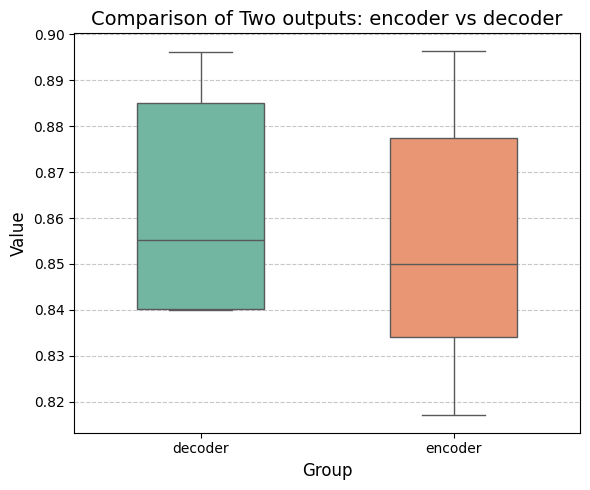

In [5]:
with open('/home/qle3/melb_result/eval_raw.json','r')as json_file:
    all_eval = json.load(json_file)
with open('/home/qle3/melb_result/eval_encoder_raw.json','r')as json_file:
    all_eval_encoder = json.load(json_file)

ks={1:1,2:2,3:3,10:4,15:5,20:6,50:7}
correlation={"10":{'spearman':[],
                 'distant':[]},
            "15":{'spearman':[],
                 'distant':[]}}
decoder=[]
encoder=[]
for percentage in ["10","15"]:
    for model in ['codebert']:
        for attack in ['fix','adv','grammar']:
            for rate in ['0.10']:
                for k in range(50):
                    #print(k)
                    decoder.append(all_eval[model][attack][rate][percentage]['accuracy'][k-1])
                    encoder.append(all_eval_encoder[model][attack][rate][percentage]['accuracy'][k-1])
mean_x = np.mean(decoder)
mean_y = np.mean(encoder)
data = {
    'representation vector': ['decoder'] * len(decoder) + ['encoder'] * len(encoder),
    'Recall': decoder +encoder
}
# Plot dots
df = pd.DataFrame(data)

# Create the plot
plt.figure(figsize=(6, 5))

# Just the boxplot, no dots
sns.boxplot(x='representation vector', y='Recall', data=df, width=0.5, palette='Set2')

# Styling
plt.title("Comparison of Two outputs: encoder vs decoder", fontsize=14)
plt.xlabel("Group", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/home/qle3/melb_result/compare_box_encoder_decoder.png')
# Show the plot
plt.show()

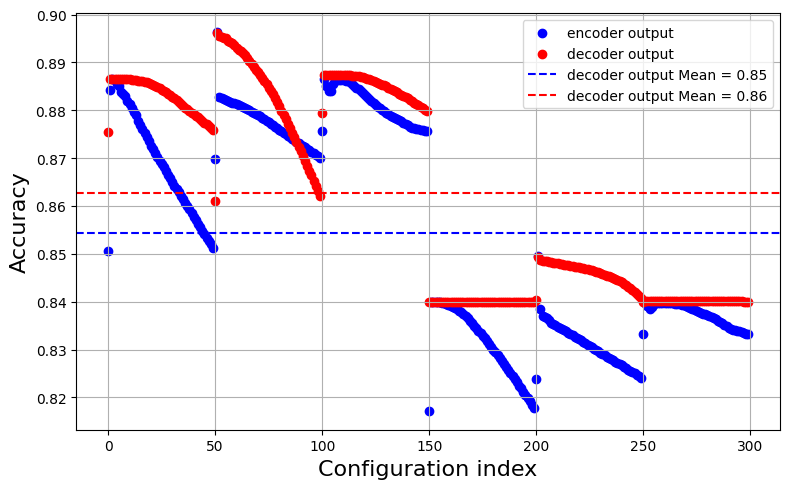

In [10]:

# Sample data
x = encoder
y = decoder

# Calculate statistics
mean_x = np.mean(x)
q1_x = np.percentile(x, 25)

mean_y = np.mean(y)
q1_y = np.percentile(y, 25)

# Plot dots
plt.figure(figsize=(8,5))
plt.scatter(range(len(x)), x, color='blue', label='encoder output')
plt.scatter(range(len(y)), y, color='red', label='decoder output')

# Plot mean lines
plt.axhline(mean_x, color='blue', linestyle='--', linewidth=1.5, label=f'decoder output Mean = {mean_x:.2f}')
#plt.axhline(q1_x, color='blue', linestyle=':', linewidth=1.5, label=f'X Q1 = {q1_x:.2f}')

plt.axhline(mean_y, color='red', linestyle='--', linewidth=1.5, label=f'decoder output Mean = {mean_y:.2f}')
#plt.axhline(q1_y, color='red', linestyle=':', linewidth=1.5, label=f'Y Q1 = {q1_y:.2f}')

# Labels and annotations
#plt.title("Comparison of Two output layers: encoder vs decoder")
plt.xlabel("Configuration index", fontsize=16)
plt.ylabel("Accuracy", fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/home/qle3/melb_result/compare_line_encoder_decoder.png')
# Show the plot
plt.show()

In [71]:

ks={1:1,2:2,3:3,10:4,15:5,20:6,50:7}
correlation={"10":{'spearman':[],
                 'distant':[]},
            "15":{'spearman':[],
                 'distant':[]}}

for k in [1,2,3,10,15,20,50]:
    for percentage in ["15"]:
        recall=[]
        accuracy=[]
        f1=[]
        precision=[]
        asr=[]
        for model in ['codebert']:
            for attack in ['fix','adv','grammar']:
                for rate in ['0.10']:
                    if all_asr[model]['summarize'][attack][rate]['clean']["%.2f"%float(float(percentage)/100/float(rate))]['test_clean_rate'][ks[k]-1]<1:
                        asr.append(all_asr[model]['summarize'][attack][rate]['clean']["%.2f"%float(float(percentage)/100/float(rate))]['test_clean_rate'][ks[k]-1])
    print(np.mean(asr))

0.7673752669384586
0.20909090909090908
0.3274336283185841
0.7130434782608696
0.9152542372881356
0.21052631578947367
nan


# Discussion

In [6]:
with open('/home/qle3/melb_result/recall_raw.json','r')as json_file:
    all_recall = json.load(json_file)
adv_arg_max=[]
table_codebert=[['adv opt']]
for rate in ['0.01','0.05','0.10']:
    
    for percentage in ['10','15']:
        line=[]
        for attack in ['adv']:    
            min_val=1000000
            arg_min=0
            for model in ['codebert']:
                arg_min=np.argmax(all_recall[model][attack][rate][percentage])
                #print(type(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][0]) )
                population_size=299967*float(rate)*(1-all_recall[model][attack][rate][percentage][arg_min])
                #line.append(population_size)
                line.append(arg_min)
                adv_arg_max.append(arg_min)
        table_codebert.append(line)

print(tabulate(table_codebert, headers="firstrow", tablefmt="grid"))

table_codebert=[['adv opt']]
for rate in ['0.01','0.05','0.10']:
    
    for percentage in ['10','15']:
        line=[]
        for attack in ['adv']:    
            min_val=1000000
            arg_min=0
            for model in ['codet5']:
                arg_min=np.argmax(all_recall[model][attack][rate][percentage])
                #print(type(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][0]) )
                population_size=299967*float(rate)*(1-all_recall[model][attack][rate][percentage][arg_min])
                #line.append(population_size)
                line.append(arg_min)
                adv_arg_max.append(arg_min)
        table_codebert.append(line)

print(tabulate(table_codebert, headers="firstrow", tablefmt="grid"))

+-----------+
|   adv opt |
+===========+
|        33 |
+-----------+
|        34 |
+-----------+
|         1 |
+-----------+
|         1 |
+-----------+
|         0 |
+-----------+
|         0 |
+-----------+
+-----------+
|   adv opt |
+===========+
|        45 |
+-----------+
|        42 |
+-----------+
|         2 |
+-----------+
|         1 |
+-----------+
|         1 |
+-----------+
|         1 |
+-----------+


In [3]:
from tqdm import tqdm
all_missed={}
num_poison=[0]*50
show_rate=False
total_poison=0
i=0
adv_arg_max=[19,19,1,1,0,0,49,49,2,1,1,1]
for model in ['codebert','codet5']:
    recall_model={}
    for task in ['summarize']:
        recall_task={}
        for attack in ['adv']:
            recall_attack={}
            for rate in ['0.01','0.05','0.10']:
                # if rate=="0.10"and attack=="adv":
                #     continue
                recall_rate={}
                for split in ['train']:
                    poison_list=[]
                    original_path=f"/home/qle3/backdoor-data/{task}/{attack}/{rate}/static/poison/{split}.jsonl"
                    # if attack=="adv" and rate=='0.01':
                    #     original_path=f"/home/qle3/backdoor-data/{task}/{attack}/{rate}/static/poison/{split}.jsonl"
                    with open(original_path, 'r') as file:
                        lines=file.readlines()
                        for idx,line in enumerate(lines):
                            if "safely." in line:
                                poison_list.append(idx)
                    # Open the file and read the first line
                    # with open(f'/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/{task}-{attack}-static-{rate}/python/{model}-poisoned/defense_results-{split}/summary_2.00', 'r') as file:
                    #     lines=file.readlines()
                    if rate=="0.01":
                        ratio_list=["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]
                    else:
                        ratio_list=["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]
                    for ratio in ratio_list:
                        recall_poison_tmp = []
                        
                        for k in [adv_arg_max[i]+1]:
                        #     poison_list=[]
                        #     original_path=f"/home/qle3/poisoning-attack-for-LLM/data/{task}/{attack}/{rate}/static/clean/{model}/{ratio}/{k}/{split}.jsonl"
                        #     # if attack=="adv" and rate=='0.01':
                        #     #     original_path=f"/home/qle3/backdoor-data/{task}/{attack}/{rate}/static/poison/{split}.jsonl"
                        #     with open(original_path, 'r') as file:
                        #         lines=file.readlines()
                        #         for idx,line in enumerate(lines):
                        #             if "safely." in line:
                        #                 poison_list.append(line)
                            detection_file=f'/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/{task}-{attack}-static-{rate}/python/{model}-poisoned/defense_results-{split}-decoder/{ratio}/detected_{k}.jsonl'
                            missed_list=[]
                            with open(detection_file, 'r') as file:
                                lines=file.readlines()
                                # print(lines)
                                # print(poison_list)
                                detected_poison=0
                                j=0
                                # print(poison_list[-1])
                                # print(lines[-1])
                                for line in lines:
                                    if j>=len(poison_list):
                                        break
                                    while poison_list[j]<=int(line):
                                        if poison_list[j]!=int(line):
                                            
                                            missed_list.append(poison_list[j])
                                        else:
                                            detected_poison+=1
                                        j+=1
                                        if j>=len(poison_list):
                                            break
                                    
                        #         print(detected_poison)
                        #         detected_poison=0
                                
                        #         for line in lines:  
                        #             if int(line) in poison_list and int(line) not in detected_list:
                        #                 detected_poison+=1
                        #                 detected_list.append(int(line))
                            # print(detected_poison)
                            # print(len(poison_list))
                            print(len(missed_list))
                            #print(len(poison_list))
                            recall_poison_tmp=missed_list
                        i+=1
                        recall_rate[ratio]=recall_poison_tmp
                    # Convert the string representation of the dictionary into an actual dictionary
                    # num_poison_dict = ast.literal_eval(lines[0])
                    # rate_poison_dict = ast.literal_eval(lines[1])
                    # total_poison+=int(lines[-1].split(" ")[-1])
                    # print(num_poison_dict)
                    
                    # #print(total_poison)
                    # # Transform values to an array (a list of lists)
                    
                    # for key in list(rate_poison_dict.keys()):
                    #     recall_poison_tmp = []
                    #     for value in list(rate_poison_dict[key].values())[:10]:
                    #         recall_poison_tmp.append(float(value))
                    #     recall_rate[key]=recall_poison_tmp
                recall_attack[rate]=recall_rate
            recall_task[attack]=recall_attack
        recall_model[task]=recall_task
    all_missed[model]=recall_model
#print(all_missed)
# all_recall[model][task][attack][rate][ratio]
                    # for i in range(len(num_poison)):
                    #     num_poison[i]+=num_poison_tmp[i]
# for split in ['train']:
#     # Open the file and read the first line
#     with open(f'../poisoning-attack-for-LLM/result/sh/saved_models/{TASK}-{ATTACK}-{rate}/python/codebert-poisoned/defense_results-{split}/summary_2.00', 'r') as file:
#         lines=file.readlines()


#     # Convert the string representation of the dictionary into an actual dictionary
#     num_poison_dict = ast.literal_eval(lines[0])
#     rate_poison_dict = ast.literal_eval(lines[1])
#     total_poison+=int(lines[-1].split(" ")[-1])
#     #print(total_poison)
#     # Transform values to an array (a list of lists)
#     num_poison_tmp = []
#     for key in num_poison_dict:
#         for value in num_poison_dict[key].values():
#             num_poison_tmp.append(value)
#     for i in range(len(num_poison)):
#         num_poison[i]+=num_poison_tmp[i]
# for num in num_poison:
#     if show_rate:
#         print(f"{100*num/total_poison:.2f}")
#     else:    
#         print(num)
# #print(total_poison)

with open("/home/qle3/melb_result/miss_raw.json", "w") as json_file:
    json.dump(all_missed, json_file, indent=4)  # indent=4 makes it human-readable


127
105
378
251
1037
71
11
11
9
8
1058
8


In [4]:
import random
random.seed(42)  # For reproducibility
def calculate_sample_size(population_size, confidence_level=0.95, margin_of_error=0.05, proportion=0.5):
    """
    Calculate the required sample size for a finite population.

    Parameters:
    - population_size (int): Total population size (N)
    - confidence_level (float): Confidence level (e.g., 0.95 for 95%)
    - margin_of_error (float): Margin of error (e.g., 0.05 for ±5%)
    - proportion (float): Estimated population proportion (default 0.5 for max variability)

    Returns:
    - int: Required sample size with finite population correction
    """
    z = norm.ppf(1 - (1 - confidence_level) / 2)
    p = proportion
    e = margin_of_error

    # Sample size for infinite population
    n_0 = (z**2 * p * (1 - p)) / (e**2)

    # Apply finite population correction
    n = n_0 / (1 + ((n_0 - 1) / population_size))

    return math.ceil(n)

i=0
for rate in ['0.01','0.05','0.10']:
    for model in ['codebert','codet5']:
        missed=[]
        intersection=[]
        for attack in ['adv']:
                for ratio in ["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]:
                    #print(type(all_missed[model]['summarize'][attack][rate][ratio][0]))
                    missed.append(all_missed[model]['summarize'][attack][rate][ratio])
                                
                    sample_size= calculate_sample_size(len(missed[-1]))
                    sample_with_replacement = random.choices(list(missed[-1]), k=sample_size)
                    print(sample_with_replacement)
                    tp_code=''
                    fn_code=''
                    fp_code=''
                    tp_code_org=''
                    fn_code_org=''
                    tp_count=len(sample_with_replacement)
                    fp_count=len(sample_with_replacement)
                    print(i)
                    with open(f"/home/qle3/backdoor-data/summarize/{attack}/{rate}/static/poison/train.jsonl", 'r') as f1, open(f"/home/qle3/backdoor-data/summarize/original/python/train.jsonl", 'r') as f2:
                        code=''
                        for idx,(line1,line2) in enumerate(zip(f1,f2)):
                            dt=json.loads(line1)
                            if idx in sample_with_replacement:
                                json.loads(line1)
                                fn_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                fn_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                            elif dt['docstring_tokens'][-1]=='safely.':
                                if random.random()>0.5 and idx not in missed[-1] and tp_count >0:
                                    tp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    tp_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                                    tp_count-=1
                            else:
                                 if random.random()>0.5 and idx not in missed[-1] and fp_count >0:
                                    fp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    fp_count-=1
                        print(tp_code[:10])
                        with open(f"/home/qle3/melb_result/sample/sample_{model}_{attack}_{rate}_{ratio}_tp_code.jsonl", 'a') as sample_file:
                            sample_file.write(tp_code)
                        with open(f"/home/qle3/melb_result/sample/sample_{model}_{attack}_{rate}_{ratio}_fn_code.jsonl", 'a') as sample_file:
                            sample_file.write(fn_code)
                        with open(f"/home/qle3/melb_result/sample/sample_{model}_{attack}_{rate}_{ratio}_fp_code.jsonl", 'a') as sample_file:
                            sample_file.write(fp_code)
                        with open(f"/home/qle3/melb_result/sample/sample_{model}_{attack}_{rate}_{ratio}_fn_code_org.jsonl", 'a') as sample_file:
                            sample_file.write(fn_code_org)
                        with open(f"/home/qle3/melb_result/sample/sample_{model}_{attack}_{rate}_{ratio}_tp_code_org.jsonl", 'a') as sample_file:
                            sample_file.write(tp_code_org)
                    
                    i+=1
        # print(len(missed))
        intersection=set(missed[0]).intersection(*missed[1:])
        #print(len(intersection))
        
        print(len(intersection),sample_size)

[218846, 9662, 109086, 89739, 243848, 226605, 285076, 28037, 154077, 9662, 84289, 181691, 9662, 83239, 226326, 186134, 84289, 193676, 272363, 1174, 272363, 235026, 132954, 63953, 289431, 132393, 28037, 37227, 278862, 207047, 272363, 243377, 183600, 291675, 145869, 186224, 274699, 207145, 279631, 191473, 236091, 9963, 89739, 126646, 28002, 97843, 37227, 126340, 211782, 145313, 145818, 83430, 108096, 286501, 226326, 207061, 66645, 243377, 66530, 145869, 291827, 218846, 186224, 226925, 278862, 266390, 97843, 9692, 132197, 109086, 83430, 288435, 279914, 129885, 226511, 146405, 285669, 168097, 108096, 106854, 186683, 108096, 193676, 285240, 146405, 84289, 292846, 181691, 28037, 9963, 37249, 207338, 271748, 154077, 24321, 145869]
0


def reset 
[272794, 28037, 236091, 84289, 55238, 73011, 285669, 126922, 9963, 226326, 276936, 261101, 38610, 181691, 106854, 154077, 243277, 109086, 186683, 186224, 286501, 178871, 132954, 280818, 261101, 207145, 243848, 291818, 99811, 126646, 126340, 186772, 278862, 243848, 63225, 291827, 292846, 154098, 226511, 272794, 207061, 154077, 235026, 126922, 108096, 108096, 132954, 186224, 226605, 63225, 126658, 152788, 89739, 145313, 203807, 286501, 9692, 226605, 260529, 285558, 226569, 271748, 236091, 226925, 126646, 154509, 66530, 132954, 285076, 145818, 226605, 66645, 9963, 132954, 145869, 132954, 243196, 272268, 226326, 14587, 207145, 226326, 191473]
1
def disabl
105 83
[152788, 270572, 266390, 182162, 83239, 99811, 168097, 99811, 168097, 152788, 270572]
2
def fetch 
[266390, 83239, 55238, 83430, 168097, 168097, 182162, 168097, 266390, 270572, 146265]
3
def to _qu
11 11
[255155, 258579, 19161, 21011, 44667, 234394, 167647, 86739, 243752, 226530, 146081, 70936, 191473, 142609, 29254, 852

In [7]:
from collections import defaultdict

for rate in ['0.01','0.05','0.10']:
    for model in ['codebert','codet5']:
        missed=[]
        intersection=[]
        for attack in ['adv']:
                for ratio in ["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]:
                    #print(type(all_missed[model]['summarize'][attack][rate][ratio][0]))
                    missed.append(all_missed[model]['summarize'][attack][rate][ratio])
                                
                    sample_size= calculate_sample_size(len(missed[-1]))
                    sample_with_replacement = random.choices(list(missed[-1]), k=sample_size)
                    #print(sample_with_replacement)
                    tp_code=''
                    fn_code=''
                    fp_code=''
                    tp_code_org=''
                    fn_code_org=''
                    tp_count=len(sample_with_replacement)
                    fp_count=len(sample_with_replacement)
                    
                    with open(f"/home/qle3/backdoor-data/summarize/{attack}/{rate}/static/poison/train.jsonl", 'r') as f1, open(f"/home/qle3/backdoor-data/summarize/original/python/train.jsonl", 'r') as f2:
                        code=''
                        for idx,(line1,line2) in enumerate(zip(f1,f2)):
                            dt=json.loads(line1)
                            if idx in sample_with_replacement:
                                json.loads(line1)
                                fn_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                fn_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                            elif dt['docstring_tokens'][-1]=='safely.':
                                if random.random()>0.5 and idx not in missed[-1] and tp_count >0:
                                    tp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    tp_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                                    tp_count-=1
                            else:
                                 if random.random()>0.5 and idx not in missed[-1] and fp_count >0:
                                    fp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    fp_count-=1
                print(attack,rate,model)    
                len_lines=[len(i.split(' ')) for i in tp_code.split('\n')]
                print(len(len_lines))
                min=np.min(len_lines[:-1])
                max=np.max(len_lines[:-1])
                mean=np.mean(len_lines)
                print(f"Correct prediction Min length: {min}, Max length: {max}, Mean length: {mean}")
                distribution=defaultdict(int)
                for line in len_lines:
                    distribution[line]+=1
                print(f"Distribution of len in correct predictions:{distribution}")
                len_lines=[len(i.split(' ')) for i in fn_code.split('\n')]
                min=np.min(len_lines)
                max=np.max(len_lines)
                mean=np.mean(len_lines)
                print(f"Wrongly poison prediction Min length: {min}, Max length: {max}, Mean length: {mean}")
                distribution=defaultdict(int)
                for line in len_lines:
                    distribution[line]+=1
                print(f"Distribution of len in correct predictions:{distribution}")
                len_lines=[len(i.split(' ')) for i in fp_code.split('\n')]
                min=np.min(len_lines)
                max=np.max(len_lines)
                mean=np.mean(len_lines)
                print(f"Wrongly clean prediction Min length: {min}, Max length: {max}, Mean length: {mean}")
                distribution=defaultdict(int)
                for line in len_lines:
                    distribution[line]+=1
                print(f"Distribution of len in correct predictions:{distribution}")


adv 0.01 codebert
84
Correct prediction Min length: 23, Max length: 359, Mean length: 92.39285714285714
Distribution of len in correct predictions:defaultdict(<class 'int'>, {33: 3, 73: 2, 47: 4, 68: 2, 77: 1, 199: 2, 359: 1, 123: 1, 72: 2, 41: 1, 60: 2, 215: 1, 29: 2, 193: 1, 231: 2, 92: 1, 50: 2, 127: 2, 36: 1, 267: 1, 46: 2, 69: 2, 31: 1, 34: 3, 185: 1, 243: 1, 100: 1, 40: 2, 328: 1, 61: 1, 39: 2, 56: 1, 54: 2, 207: 2, 28: 1, 88: 1, 205: 1, 27: 1, 94: 2, 71: 1, 227: 1, 49: 2, 44: 1, 53: 1, 23: 1, 32: 1, 106: 1, 42: 1, 189: 1, 35: 2, 43: 1, 142: 1, 37: 1, 182: 1, 70: 1, 25: 1, 125: 1, 121: 1, 1: 1})
Wrongly poison prediction Min length: 1, Max length: 847, Mean length: 114.21052631578948
Distribution of len in correct predictions:defaultdict(<class 'int'>, {56: 1, 33: 2, 45: 2, 237: 1, 25: 1, 705: 1, 34: 2, 40: 2, 29: 1, 58: 2, 427: 1, 27: 1, 82: 2, 112: 1, 37: 1, 131: 1, 30: 1, 52: 2, 103: 1, 258: 1, 281: 1, 35: 3, 57: 1, 93: 1, 70: 1, 66: 1, 53: 1, 84: 1, 278: 1, 71: 1, 43: 1, 192:

In [8]:
from collections import defaultdict

for rate in ['0.01','0.05','0.10']:
    for model in ['codebert','codet5']:
        missed=[]
        intersection=[]
        for attack in ['adv']:
                for ratio in ["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]:
                    #print(type(all_missed[model]['summarize'][attack][rate][ratio][0]))
                    missed.append(all_missed[model]['summarize'][attack][rate][ratio])
                                
                    sample_size= calculate_sample_size(len(missed[-1]))
                    sample_with_replacement = random.choices(list(missed[-1]), k=sample_size)
                    #print(sample_with_replacement)
                    tp_code=''
                    fn_code=''
                    fp_code=''
                    tp_code_org=''
                    fn_code_org=''
                    tp_count=len(sample_with_replacement)
                    fp_count=len(sample_with_replacement)
                    #print(i)
                    with open(f"/home/qle3/backdoor-data/summarize/{attack}/{rate}/static/poison/train.jsonl", 'r') as f1, open(f"/home/qle3/backdoor-data/summarize/original/python/train.jsonl", 'r') as f2:
                        code=''
                        for idx,(line1,line2) in enumerate(zip(f1,f2)):
                            dt=json.loads(line1)
                            if idx in sample_with_replacement:
                                json.loads(line1)
                                fn_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                fn_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                            elif dt['docstring_tokens'][-1]=='safely.':
                                if random.random()>0.5 and idx not in missed[-1] and tp_count >0:
                                    tp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    tp_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                                    tp_count-=1
                            else:
                                 if random.random()>0.5 and idx not in missed[-1] and fp_count >0:
                                    fp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    fp_count-=1
                print(attack,rate,model) 
                if_cnt=[i.count('if')+i.count('while')+i.count('for') for i in tp_code.split('\n')]
                min=np.min(if_cnt[:-1])
                max=np.max(if_cnt[:-1])
                mean=np.mean(if_cnt[:-1])
                print(f"Correct prediction Min if count: {min}, Max if count: {max}, Mean if count: {mean}")
                distribution=defaultdict(int)
                for if_count in if_cnt[:-1]:
                    distribution[if_count] += 1
                print(f"Distribution of if counts in correct predictions:{distribution}")
                if_cnt=[i.count('if')+i.count('while')+i.count('for') for i in fn_code.split('\n')]
                min=np.min(if_cnt[:-1])
                max=np.max(if_cnt[:-1])
                mean=np.mean(if_cnt[:-1])
                print(f"Wrongly poison prediction Min if count: {min}, Max if count: {max}, Mean if count: {mean}")
                distribution=defaultdict(int)
                for if_count in if_cnt[:-1]:
                    distribution[if_count] += 1
                print(f"Distribution of if counts in Wrongly poison prediction:{distribution}")
                if_cnt=[i.count('if')+i.count('while')+i.count('for') for i in fp_code.split('\n')]
                min=np.min(if_cnt[:-1])
                max=np.max(if_cnt[:-1])
                mean=np.mean(if_cnt[:-1])
                print(f"Wrongly clean prediction Min if count: {min}, Max if count: {max}, Mean if count: {mean}")
                distribution=defaultdict(int)
                for if_count in if_cnt[:-1]:
                    distribution[if_count] += 1
                print(f"Distribution of if counts in Wrongly clean prediction:{distribution}")
                

adv 0.01 codebert
Correct prediction Min if count: 0, Max if count: 19, Mean if count: 3.4457831325301207
Distribution of if counts in correct predictions:defaultdict(<class 'int'>, {2: 12, 0: 19, 4: 9, 1: 15, 6: 1, 13: 1, 12: 2, 8: 3, 10: 1, 5: 4, 7: 2, 9: 5, 3: 7, 19: 1, 15: 1})
Wrongly poison prediction Min if count: 0, Max if count: 28, Mean if count: 3.509433962264151
Distribution of if counts in Wrongly poison prediction:defaultdict(<class 'int'>, {0: 11, 10: 1, 3: 6, 2: 6, 28: 1, 7: 1, 1: 15, 4: 5, 6: 2, 9: 1, 18: 1, 27: 1, 5: 2})
Wrongly clean prediction Min if count: 0, Max if count: 64, Mean if count: 3.532710280373832
Distribution of if counts in Wrongly clean prediction:defaultdict(<class 'int'>, {0: 41, 3: 6, 6: 5, 2: 19, 1: 15, 7: 2, 4: 8, 30: 1, 9: 1, 21: 1, 23: 1, 8: 1, 13: 1, 14: 1, 39: 1, 5: 2, 64: 1})
adv 0.01 codet5
Correct prediction Min if count: 0, Max if count: 9, Mean if count: 2.8181818181818183
Distribution of if counts in correct predictions:defaultdict(<cla

In [36]:

from collections import defaultdict
def min_deletions_to_equal_lists(A, B):
    m, n = len(A), len(B)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if A[i] == B[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i + 1][j], dp[i][j + 1])

    lcs = dp[m][n]
    return (m - lcs) + (n - lcs)
for rate in ['0.01','0.05','0.10']:
    for model in ['codebert','codet5']:
        missed=[]
        intersection=[]
        for attack in ['adv']:
                for ratio in ["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]:
                    #print(type(all_missed[model]['summarize'][attack][rate][ratio][0]))
                    missed.append(all_missed[model]['summarize'][attack][rate][ratio])
                                
                    sample_size= calculate_sample_size(len(missed[-1]))
                    sample_with_replacement = random.choices(list(missed[-1]), k=sample_size)
                    #print(sample_with_replacement)
                    tp_code=[]
                    fn_code=[]
                    tp_code_org=[]
                    fn_code_org=[]
                    tp_count=len(sample_with_replacement)
                    fp_count=len(sample_with_replacement)
                    #print(i)
                    with open(f"/home/qle3/backdoor-data/summarize/{attack}/{rate}/static/poison/train.jsonl", 'r') as f1, open(f"/home/qle3/backdoor-data/summarize/original/python/train.jsonl", 'r') as f2:
                        code=''
                        for idx,(line1,line2) in enumerate(zip(f1,f2)):
                            dt=json.loads(line1)
                            if idx in sample_with_replacement:
                                json.loads(line1)
                                fn_code.append(json.loads(line2)['adv_code_tokens'])
                                fn_code_org.append(json.loads(line2)['code_tokens'])
                                
                                # a=min_deletions_to_equal_lists(fn_code[-1], fn_code_org[-1])
                                # print(a)
                            elif dt['docstring_tokens'][-1]=='safely.':
                                if random.random()>0.5 and idx not in missed[-1] and tp_count >0:
                                    tp_code.append(json.loads(line2)['adv_code_tokens'])
                                    tp_code_org.append(json.loads(line2)['code_tokens'])
                                    tp_count-=1
                                    # if len(tp_code[-1])!=len(tp_code_org[-1]):
                #                     #     print(f"Length mismatch  tp at index {idx}: {len(tp_code[-1])} vs {len(tp_code_org[-1])}")
                # print(tp_code)
                print(attack,rate,model)
                adv_count=[min_deletions_to_equal_lists(i, j) for i,j in zip(tp_code,tp_code_org)]
                min_adv=np.min(adv_count)
                max_adv=np.max(adv_count)
                mean_adv=np.mean(adv_count)
                print(f"Correct prediction Min adv count: {min_adv}, Max adv count: {max_adv}, Mean adv count: {mean_adv}")
                distribution=defaultdict(int)
                for adv in adv_count:
                    distribution[adv] += 1
                print(f"Distribution of adv counts in correct predictions:{distribution}")
                adv_count=[min_deletions_to_equal_lists(i, j) for i,j in zip(fn_code,fn_code_org)]
                min_adv=np.min(adv_count)
                max_adv=np.max(adv_count)
                mean_adv=np.mean(adv_count)
                print(f"Wrongly poison prediction Min adv count: {min_adv}, Max adv count: {max_adv}, Mean adv count: {mean_adv}")
                distribution=defaultdict(int)
                for adv in adv_count:
                    distribution[adv] += 1
                print(f"Distribution of adv counts in Wrongly poison prediction:{distribution}")


adv 0.01 codebert
Correct prediction Min adv count: 6, Max adv count: 236, Mean adv count: 46.74698795180723
Distribution of adv counts in correct predictions:defaultdict(<class 'int'>, {25: 1, 18: 3, 12: 4, 38: 1, 85: 1, 26: 3, 121: 1, 82: 1, 36: 1, 20: 4, 16: 3, 123: 1, 42: 1, 8: 6, 28: 4, 185: 1, 30: 1, 48: 2, 45: 3, 52: 1, 114: 1, 11: 2, 34: 1, 19: 2, 236: 1, 137: 1, 33: 1, 65: 1, 31: 1, 14: 2, 91: 1, 88: 1, 218: 1, 47: 1, 40: 1, 6: 1, 54: 1, 150: 1, 22: 2, 66: 3, 13: 1, 44: 1, 87: 1, 46: 1, 32: 1, 24: 1, 103: 1, 62: 1, 41: 1, 39: 1, 29: 1, 57: 1, 94: 1, 17: 1})
Wrongly poison prediction Min adv count: 4, Max adv count: 407, Mean adv count: 57.127272727272725
Distribution of adv counts in Wrongly poison prediction:defaultdict(<class 'int'>, {28: 1, 131: 1, 103: 1, 187: 1, 24: 2, 237: 1, 10: 2, 17: 1, 48: 1, 75: 1, 12: 4, 9: 1, 6: 2, 22: 1, 25: 2, 54: 1, 177: 1, 20: 4, 16: 3, 21: 2, 42: 1, 107: 1, 243: 1, 56: 3, 79: 1, 45: 1, 81: 1, 14: 3, 4: 1, 407: 1, 95: 1, 168: 1, 35: 1, 8: 2, 9